In [50]:
# @title
%%html
<div style="
  background-color: #e6eefc;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: center;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 26px;
    font-weight: 600;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    Performer FAVOR+ Attention Head Replacement in TinyLlama 1.1B Model – Computation Speed and Approximation Convergence Analysis
  </h1>
</div>

In [51]:
# @title

%%html
<div style="
  background-color: #e6eefc;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: center;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 26px;
    font-weight: 600;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    0. Setup
  </h1>
</div>

## **0.1 Imports and model load from repository**

In [52]:
import sys, os, time
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import copy
import matplotlib.pyplot as plt
import torch, subprocess, sys

In [53]:
!git clone https://github.com/Antoinechss/Performer-attention-LLM.git
!pip install -q "transformers>=4.40.0" accelerate sentencepiece protobuf

REPO_DIR = "/content/Performer-attention-LLM"

print(f"GPU: {torch.cuda.get_device_name(0)}")

print("Triton available:", end=" ")
try:
    import triton
    print("Yes")
except ImportError:
    print("No")

fatal: destination path 'Performer-attention-LLM' already exists and is not an empty directory.
GPU: Tesla T4
Triton available: Yes


In [54]:
sys.path.insert(0, os.path.join(REPO_DIR, 'performer'))
from performer_attention import PerformerAttentionCore, _HAS_TRITON

# ── Config ──────────────────────────────────────────────────────
MODEL          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
PROMPT         = "<|user|>\nHow do I get a good night's sleep?</s>\n<|assistant|>\n"
MAX_NEW_TOKENS = 30
DTYPE          = torch.float16
DEVICE         = "cuda"

print(f"Triton kernel loaded: {_HAS_TRITON}")
print(f"Device: {DEVICE}, dtype: {DTYPE}")

Triton kernel loaded: True
Device: cuda, dtype: torch.float16


## **0.2 Class for mixed performer / softmax attention heads**

In [55]:
class MixedPerformerAttention(torch.nn.Module):
    """Wraps a HuggingFace LlamaAttention, routing some heads through FAVOR+."""

    def __init__(self, original_attn, num_performer_heads):
        super().__init__()
        self.original = original_attn
        self.head_dim = original_attn.head_dim
        self.num_heads = original_attn.config.num_attention_heads
        self.num_key_value_heads = original_attn.config.num_key_value_heads
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.scaling = self.head_dim ** -0.5
        self.num_performer_heads = num_performer_heads
        self.num_standard_heads = self.num_heads - num_performer_heads

        self.q_proj = original_attn.q_proj
        self.k_proj = original_attn.k_proj
        self.v_proj = original_attn.v_proj
        self.o_proj = original_attn.o_proj

        self.performer_core = PerformerAttentionCore(
            head_dim=self.head_dim, num_features=256
        ).to(DEVICE)

        self.config = original_attn.config
        self.layer_idx = original_attn.layer_idx
        self.is_causal = True

    def _rotate_half(self, x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)

    def _apply_rotary(self, q, k, cos, sin):
        cos = cos.unsqueeze(1)
        sin = sin.unsqueeze(1)
        return (q * cos) + (self._rotate_half(q) * sin), (k * cos) + (self._rotate_half(k) * sin)

    def forward(self, hidden_states, position_embeddings=None,
                attention_mask=None, past_key_values=None, **kwargs):
        B, N, _ = hidden_states.shape

        q = self.q_proj(hidden_states).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        cos, sin = position_embeddings
        q, k = self._apply_rotary(q, k, cos, sin)

        if past_key_values is not None:
            k, v = past_key_values.update(k, v, self.layer_idx)

        # Expand K/V for GQA
        if self.num_key_value_groups > 1:
            k = k.repeat_interleave(self.num_key_value_groups, dim=1)
            v = v.repeat_interleave(self.num_key_value_groups, dim=1)

        if attention_mask is None and N > 1 and self.num_standard_heads > 0:
            key_len = k.shape[2]
            causal = torch.full((N, key_len), torch.finfo(q.dtype).min,
                                device=q.device, dtype=q.dtype)
            attention_mask = torch.triu(causal, diagonal=key_len - N + 1)[None, None]

        if self.num_standard_heads == 0:
            attn_out = self.performer_core(q, k, v)
        elif self.num_performer_heads == 0:
            scores = torch.matmul(q, k.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q.dtype)
            attn_out = torch.matmul(w, v)
        else:
            Kp = self.num_performer_heads
            out_p = self.performer_core(q[:, :Kp], k[:, :Kp], v[:, :Kp])
            q_s, k_s, v_s = q[:, Kp:], k[:, Kp:], v[:, Kp:]
            scores = torch.matmul(q_s, k_s.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q_s.dtype)
            out_s = torch.matmul(w, v_s)
            attn_out = torch.cat([out_p, out_s], dim=1)

        attn_out = attn_out.transpose(1, 2).contiguous().reshape(B, N, -1)
        return self.o_proj(attn_out), None

## **0.3 Standard and Hybrid performer models setup**

Tune `NUM_PERF_HEADS` to replace 0 to 32 of the attention heads by performer approximation.


In [56]:
# Load 2 classic models
std_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
std_model.eval()
perf_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
perf_model.eval()

num_heads = std_model.config.num_attention_heads

# -- Tune number of attention heads replaced (0->32)
NUM_PERF_HEADS = 4
# -----------------------------------

# Monkey-patch attention layers in perf_model
for layer in perf_model.model.layers:
    layer.self_attn = MixedPerformerAttention(
        layer.self_attn, num_performer_heads=NUM_PERF_HEADS
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL)
prompt_ids = tokenizer(PROMPT, return_tensors="pt")["input_ids"].to(DEVICE)

print(f"Models loaded. Heads replaced: {NUM_PERF_HEADS}/{num_heads} performer.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Models loaded. Heads replaced: 4/32 performer.


## **0.4 Correctness Checkpoint Test : Setting 0/32 Performer Heads and observing equivalence**

In [57]:
# Setting 0/32 performer heads in second model
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = 0
    layer.self_attn.num_standard_heads = num_heads

with torch.no_grad():
    std_out = std_model(input_ids=prompt_ids, use_cache=False)
    perf_out = perf_model(input_ids=prompt_ids, use_cache=False)

std_logits = std_out.logits[0].float()
perf_logits = perf_out.logits[0].float()

max_diff = (std_logits - perf_logits).abs().max().item()
mean_diff = (std_logits - perf_logits).abs().mean().item()
cos_sim = F.cosine_similarity(std_logits, perf_logits, dim=-1).mean().item()

# Also check last-token distribution
std_probs = F.softmax(std_logits[-1], dim=-1)
perf_probs = F.softmax(perf_logits[-1], dim=-1)
kl = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()

print("Baseline equivalence test 0 performer heads")
print("")
print(f"Max abs difference on logits   |  {max_diff:.6f}")
print(f"Mean abs difference on logits  |  {mean_diff:.6f}")
print(f"Average Cosine similarity      |  {cos_sim:.6f}")
print(f"KL divergence of last token    |  {kl:.6f}")

# Restore
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads = num_heads - NUM_PERF_HEADS

Baseline equivalence test 0 performer heads

Max abs difference on logits   |  0.058594
Mean abs difference on logits  |  0.003977
Average Cosine similarity      |  0.999998
KL divergence of last token    |  0.000030


In [58]:
# @title
%%html
<div style="
  background-color: lightgreen;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    Stats above confirm equivalence of classic model and hybrid performer model with MixedAttentionHead set to 0 performer heads
  </h1>
</div>

In [59]:
# @title

%%html
<div style="
  background-color: #e6eefc;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: center;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 26px;
    font-weight: 600;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    1. Generation Quality Analysis:
    Studying how both models respond to a given prompt
  </h1>
</div>

## **1.1 Generation degradation across layers**

Setting first `n=0,1,2...` layers to full performer attention architecture and rest to softmax attention. Approximation error accumulates across layers.

In [60]:
print("Layerwise replacement: first n layers set to 32/32 performer heads, rest softmax")
print(f"Each replaced layer uses all {num_heads} heads as performer (M=256)\n")

with torch.no_grad():
    std_ref = std_model(input_ids=prompt_ids, use_cache=False)
std_logits_ref = std_ref.logits[0, -1].float()
std_probs_ref = F.softmax(std_logits_ref, dim=-1)
std_top1_id = std_logits_ref.argmax().item()

n_layers = len(perf_model.model.layers)

print(f"{'Layers':>8}  {'KL':>8}  {'cos_sim':>8}  {'p(top1)':>8}")
print("-" * 40)

for n_perf_layers in [0, 1, 2, 3, 4, 5, 10, 20, 30]:
    for i, layer in enumerate(perf_model.model.layers):
        if i < n_perf_layers:
            layer.self_attn.num_performer_heads = num_heads
            layer.self_attn.num_standard_heads = 0
        else:
            layer.self_attn.num_performer_heads = 0
            layer.self_attn.num_standard_heads = num_heads

    with torch.no_grad():
        out = perf_model(input_ids=prompt_ids, use_cache=False)
    logits = out.logits[0, -1].float()
    probs = F.softmax(logits, dim=-1)
    kl = F.kl_div(probs.log(), std_probs_ref, reduction='sum').item()
    cos = F.cosine_similarity(logits.unsqueeze(0), std_logits_ref.unsqueeze(0)).item()
    p_top1 = probs[std_top1_id].item()

    print(f"{n_perf_layers:>8}  {kl:>8.3f}  {cos:>8.4f}  {p_top1:>8.1%}")

# Restore
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads = num_heads - NUM_PERF_HEADS

Layerwise replacement: first n layers set to 32/32 performer heads, rest softmax
Each replaced layer uses all 32 heads as performer (M=256)

  Layers        KL   cos_sim   p(top1)
----------------------------------------
       0     0.000    1.0000     29.5%
       1     0.108    0.9836     32.2%
       2     2.916    0.6556      0.4%
       3     6.297    0.5907      0.0%
       4     6.093    0.6018      0.0%
       5     6.188    0.6062      0.0%
      10     6.346    0.6265      0.0%
      20     5.489    0.6331      0.0%
      30     5.643    0.6098      0.0%


In [61]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    With a 100% (32/32 heads) performer architecture, the generation quality massively degrades as soon as the second layer.
    A small divergence massively propagates through the model layers
  </h1>
</div>

## **1.2 Response to prompt: per-token distribution comparison (4/32 heads replaced)**


In [62]:
for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = NUM_PERF_HEADS
    layer.self_attn.num_standard_heads  = num_heads - NUM_PERF_HEADS

print(f"Generation benchmark [{NUM_PERF_HEADS}/{num_heads} performer heads]")
print(" ")
print("Reponse to prompt : How do I get a good night's sleep?")
print(" ")

W = 14
hdr = f"{'Step':>4}  {'Classic':.<{W}}  {'Performer':.<{W}}  {'p(cls)':>7}  {'p_perf(cls)':>11}  {'KL':>6}"
print(hdr)
print("-" * len(hdr))

current_ids = prompt_ids.clone()
classic_tokens, perf_tokens = [], []
kl_per_step = []

with torch.no_grad():
    for step in range(1, MAX_NEW_TOKENS + 1):
        std_out  = std_model(input_ids=current_ids,  use_cache=False)
        perf_out = perf_model(input_ids=current_ids, use_cache=False)

        std_logits  = std_out.logits[0, -1].float()
        perf_logits = perf_out.logits[0, -1].float()
        std_probs  = F.softmax(std_logits,  dim=-1)
        perf_probs = F.softmax(perf_logits, dim=-1)

        classic_id = std_logits.argmax().item()
        perf_id    = perf_logits.argmax().item()
        classic_p  = std_probs[classic_id].item()
        perf_p_cls = perf_probs[classic_id].item()
        kl         = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()

        c_tok = repr(tokenizer.decode([classic_id]))[1:-1]
        p_tok = repr(tokenizer.decode([perf_id]))[1:-1]
        print(f"{step:>4}  {c_tok:<{W}}  {p_tok:<{W}}  {classic_p:>6.1%}  {perf_p_cls:>11.1%}  {kl:>6.2f}")

        classic_tokens.append(classic_id)
        perf_tokens.append(perf_id)
        kl_per_step.append(kl)

        current_ids = torch.cat([current_ids, torch.tensor([[classic_id]], device=DEVICE)], dim=-1)
        if classic_id == tokenizer.eos_token_id:
            break

Generation benchmark [4/32 performer heads]
 
Reponse to prompt : How do I get a good night's sleep?
 
Step  Classic.......  Performer.....   p(cls)  p_perf(cls)      KL
------------------------------------------------------------------
   1  To              To               29.2%        28.6%    0.56
   2  get             get              96.3%        85.5%    0.07
   3  a               a                95.2%        94.2%    0.00
   4  good            good             99.7%        98.3%    0.01
   5  night           night            99.9%        99.8%    0.00
   6  '               '                99.9%        99.6%    0.00
   7  s               s               100.0%        94.4%    0.06
   8  sleep           sleep            99.9%        99.7%    0.00
   9  ,               ,                98.6%        98.1%    0.01
  10  here            you              24.1%         1.5%    0.70
  11  are             are              99.4%        96.0%    0.02
  12  some            some           

In [63]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    With 4/32 heads replaced, generation is close to the original softmax model with a few dismatches. Replacing
    more attention heads with performer shows degrading results.
  </h1>
</div>

In [65]:
# @title

%%html
<div style="
  background-color: #e6eefc;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: center;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 26px;
    font-weight: 600;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    2. Computation speed analysis
  </h1>
</div>

In [81]:
try:
    from triton_scan import triton_scan_forward as _triton_scan_raw
    from triton_scan import triton_decode_forward as _triton_decode_raw
except ImportError:
    _triton_scan_raw = _triton_decode_raw = None

_CUDA = torch.cuda.is_available()
_dev  = torch.device("cuda" if _CUDA else "cpu")
_TRITON = _HAS_TRITON and _CUDA

H, D     = 32, 64
M_VALS   = [128, 256]
REPEATS  = 10
scale    = D ** -0.25
ELEM_STD = D ** -0.25

performer_cores = {m: PerformerAttentionCore(head_dim=D, num_features=m).to(_dev) for m in M_VALS}

def time_fn(fn, repeats=REPEATS):
    # Warmup
    fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeats * 1000

## **2.1 `Prefill` step speed benchmark**


In [67]:

print(f"Prefill step  |  H={H} D={D}")
print(" ")

SEQ_LENS = [256, 512, 1024, 2048, 4096]
_CW = 12

hdr = f"{'N':>6}  {'Classic (ms)':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr)
print("-" * len(hdr))

b1_results = []
with torch.no_grad():
    for N in SEQ_LENS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        e2e_times = {}
        for m in M_VALS:
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            e2e_times[m] = time_fn(fn)
            row += f"  {e2e_times[m]:>{_CW}.2f}"

        best = min(e2e_times.values())
        speedup = std_ms / best
        row += f"  {speedup:>7.2f}x"
        print(row)
        b1_results.append((N, std_ms, e2e_times, speedup))

Prefill step  |  H=32 D=64
 
     N  Classic (ms)    Perf M=128    Perf M=256   speedup
----------------------------------------------------------
   256     0.26          1.05          1.72     0.24x
   512     0.55          2.07          3.28     0.27x
  1024     2.03          4.09          5.15     0.50x
  2048     7.99          7.49          9.85     1.07x
  4096    39.75         12.95         19.78     3.07x


## **2.2 `Decode` step speed benchmark**

In [68]:
print(f"Decode step")
print("")

CACHE_SIZES = [64, 256, 1024, 4096]
_CW = 12

hdr2 = f"{'Context':>6}  {'Classic':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr2)
print("-" * len(hdr2))

with torch.no_grad():
    for N in CACHE_SIZES:
        q_new = torch.randn(1, H, 1, D, device=_dev, dtype=torch.float32)
        k_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)
        v_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)

        def std_decode():
            w = torch.softmax(torch.matmul(q_new, k_all.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v_all)

        std_ms = time_fn(std_decode)
        row = f"{N:>6}  {std_ms:>7.3f}"

        best_perf = float('inf')
        for m in M_VALS:
            core      = performer_cores[m]
            phi_k_all = core.phi(k_all * scale, is_query=False)
            kv_state  = torch.einsum("bhnm,bhnd->bhmd", phi_k_all, v_all).float()
            k_state   = phi_k_all.sum(dim=2).float()
            omega_m   = core.omega.float()

            if _TRITON and _triton_decode_raw is not None:
                fn = lambda kv=kv_state, ks=k_state, om=omega_m: \
                    _triton_decode_raw((q_new * scale).float(), om, kv, ks)
            else:
                def fn(kv=kv_state, ks=k_state, c=core):
                    phi_q = c.phi(q_new * scale, is_query=True)
                    out   = torch.einsum("bhnm,bhmd->bhnd", phi_q, kv)
                    denom = torch.einsum("bhnm,bhm->bhn", phi_q, ks) + 1e-6
                    return out / denom.unsqueeze(-1)

            t = time_fn(fn)
            best_perf = min(best_perf, t)
            row += f"  {t:>{_CW}.3f}"

        row += f"  {std_ms/best_perf:>7.2f}x"
        print(row)

Decode step

Context   Classic    Perf M=128    Perf M=256   speedup
-------------------------------------------------------
    64    0.171         0.123         0.249     1.39x
   256    0.095         0.118         0.245     0.80x
  1024    0.091         0.116         0.239     0.78x
  4096    0.292         0.118         0.247     2.48x


## **2.3 Speed comparaison plots**

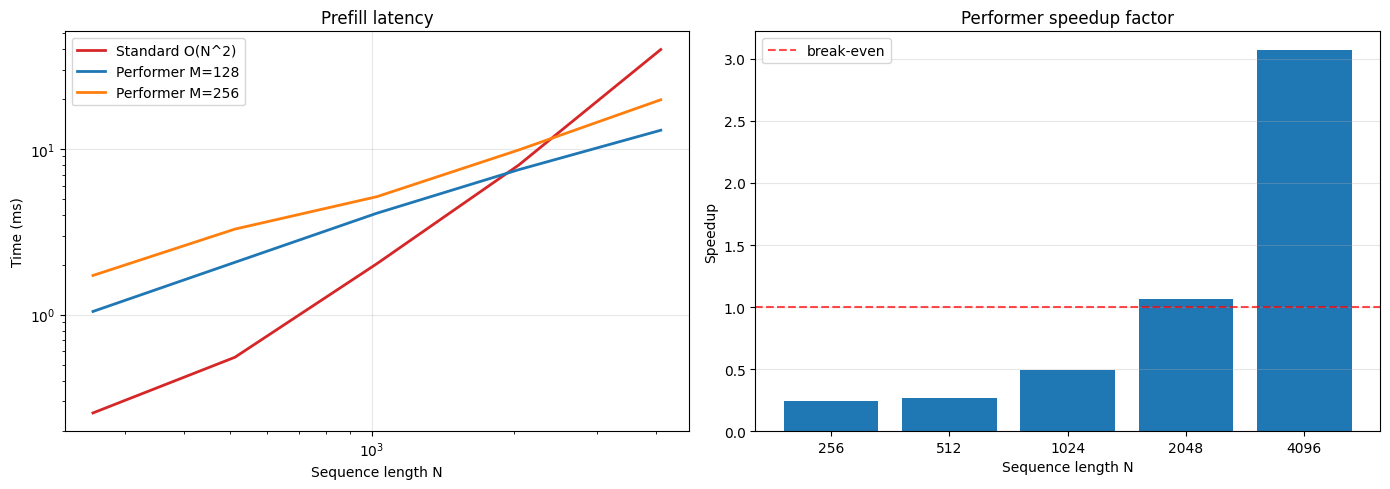

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prefill scaling
ax = axes[0]
ns = [r[0] for r in b1_results]
std_times = [r[1] for r in b1_results]
ax.plot(ns, std_times, label='Standard O(N^2)', linewidth=2, color='tab:red')
for m in M_VALS:
    perf_times = [r[2][m] for r in b1_results]
    ax.plot(ns, perf_times, label=f'Performer M={m}', linewidth=2)
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Prefill latency')
ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot speedup
ax2 = axes[1]
speedups = [r[3] for r in b1_results]
ax2.bar([str(n) for n in ns], speedups)
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='break-even')
ax2.set_xlabel('Sequence length N')
ax2.set_ylabel('Speedup')
ax2.set_title('Performer speedup factor')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **2.4 Computation speed equivalence for close M and N dimensions O(NxM) = O(N^2)**

### **2.4.1 Small N regime**

In [70]:
N_VALS = [32, 64, 128, 256, 512, 1024, 2048, 4096]
E1_M_VALS = [64, 128]

print(f"Fix M, vary N  |  H={H} D={D}")
print("")

hdr = (
    f"{'N':>6}  {'Classic':>8}"
    + "".join(f"  {'Perf M='+str(m):>10}" for m in E1_M_VALS)
    + f"  {'Speedup':>8}"
)
print(hdr)
print("-" * len(hdr))

e1_results = []  # list of (N, std_ms, {m: perf_ms}, speedup)

with torch.no_grad():
    for N in N_VALS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        perf_times = {}
        for m in E1_M_VALS:
            if m not in performer_cores:
                performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            perf_times[m] = time_fn(fn)
            row += f"  {perf_times[m]:>9.2f}"

        # --- Speedup vs best Performer ---
        best_perf = min(perf_times.values())
        speedup = std_ms / best_perf
        row += f"  {speedup:>7.2f}x"

        print(row)
        e1_results.append((N, std_ms, perf_times, speedup))

Fix M, vary N  |  H=32 D=64

     N   Classic   Perf M=64  Perf M=128   Speedup
--------------------------------------------------
    32     0.22       0.77       0.78     0.29x
    64     0.10       0.75       0.75     0.13x
   128     0.09       0.82       0.80     0.11x
   256     0.14       1.02       0.90     0.16x
   512     0.53       2.00       1.56     0.34x
  1024     2.00       4.73       3.08     0.65x
  2048     8.01       9.55       6.08     1.32x
  4096    39.28      16.80      12.25     3.21x


In [71]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    When N is small, the quadratic cost N^2 is cheap, so performer offers no speedup benefit
  </h1>
</div>

### **2.4.2 Large M regime**

In [72]:
N = 2048
M_VALS = [32, 64, 128, 256, 512, 1024, 2048]

# ---------------------------------------------
# Standard attention baseline for this N
# ---------------------------------------------
with torch.no_grad():
    q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
    k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
    v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

    def std_attn():
        w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
        return torch.matmul(w, v)

    e2_std_ms = time_fn(std_attn)
print(f"Standard attention baseline at N={N}: {e2_std_ms:.2f} ms\n")


print(f"{'M':>6}  {'M/D':>5}  {'M/N':>5}  {'Perf(ms)':>9}  {'Speedup':>8}")
print("-" * 45)

e2_results = []

with torch.no_grad():
    for m in M_VALS:
        if m not in performer_cores:
            performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
        core = performer_cores[m]
        fn = lambda c=core: c(q, k, v)
        perf_ms = time_fn(fn)
        speedup = e2_std_ms / perf_ms

        print(f"{m:>6}  {m/D:>5.1f}  {m/N:>5.2f}  {perf_ms:>8.2f}  {speedup:>7.2f}x")
        e2_results.append((m, perf_ms, speedup))


Standard attention baseline at N=2048: 7.93 ms

     M    M/D    M/N   Perf(ms)   Speedup
---------------------------------------------
    32    0.5   0.02      4.11     1.93x
    64    1.0   0.03      8.58     0.92x
   128    2.0   0.06      6.08     1.31x
   256    4.0   0.12      9.89     0.80x
   512    8.0   0.25    144.60     0.05x
  1024   16.0   0.50    650.66     0.01x
  2048   32.0   1.00   1286.72     0.01x


In [73]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    As M increases, performer cost O(N*M) grows linearly.
    When M reaches N, the cost equals O(N^2) same as standard attention.
  </h1>
</div>

### **2.4.3 Plots for computation speed convergence for close M and N values**

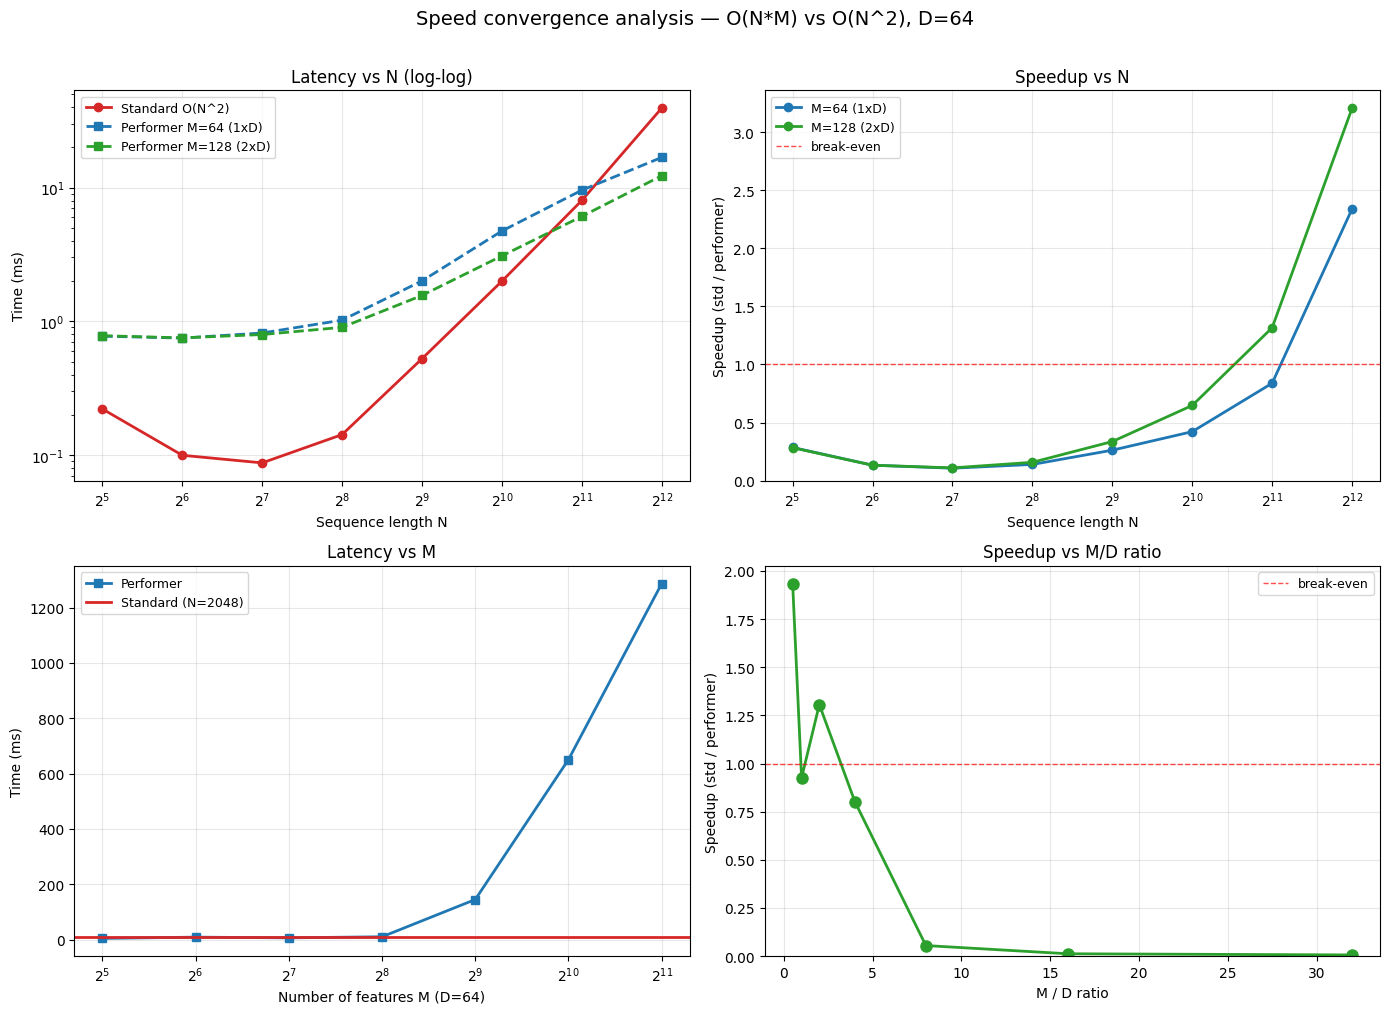

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------------
# Latency curves vs N (log-log scale)
# -----------------------------------

ax = axes[0, 0]
e1_ns = [r[0] for r in e1_results]
e1_std = [r[1] for r in e1_results]
ax.plot(e1_ns, e1_std, 'o-', label='Standard O(N^2)', linewidth=2, color='tab:red')
colors = ['tab:blue', 'tab:green', 'tab:purple']
for i, m in enumerate(E1_M_VALS):
    perf = [r[2][m] for r in e1_results]
    ax.plot(e1_ns, perf, 's--', label=f'Performer M={m} ({m//D}xD)', linewidth=2, color=colors[i])
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Latency vs N (log-log)')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# -----------------------------------
# Speedup vs N
# -----------------------------------

ax = axes[0, 1]
for i, m in enumerate(E1_M_VALS):
    speedups = [r[1] / r[2][m] for r in e1_results]
    ax.plot(e1_ns, speedups, 'o-', label=f'M={m} ({m//D}xD)', linewidth=2, color=colors[i])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup vs N')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# -----------------------------------
# Latency vs M
# -----------------------------------

ax = axes[1, 0]
e2_ms = [r[0] for r in e2_results]
e2_perf = [r[1] for r in e2_results]
ax.plot(e2_ms, e2_perf, 's-', label='Performer', linewidth=2, color='tab:blue')
ax.axhline(y=e2_std_ms, color='tab:red', linewidth=2, label=f'Standard (N={N})')
ax.set_xlabel(f'Number of features M (D={D})')
ax.set_ylabel('Time (ms)')
ax.set_title('Latency vs M')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# -----------------------------------
# Speedup vs M/D ratio
# -----------------------------------

ax = axes[1, 1]
e2_md_ratios = [m / D for m in e2_ms]
e2_speedups = [r[2] for r in e2_results]
ax.plot(e2_md_ratios, e2_speedups, 'o-', linewidth=2, color='tab:green', markersize=8)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('M / D ratio')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup vs M/D ratio')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.suptitle(f'Speed convergence analysis — O(N*M) vs O(N^2), D={D}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [76]:
# @title

%%html
<div style="
  background-color: #e6eefc;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: center;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 26px;
    font-weight: 600;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    3. Generation independent attention approximation convergence analysis
  </h1>
</div>

### This section validates the pure FAVOR+ mathematical approximation of softmax, independent of the Q and K model vectors. Simulating pretrained model Q/K norms with random vectors

## **3.0 Defining a standard softmax causal attention to benchmark against**

In [77]:
def causal_softmax_attention(q, k, v):
    """Standard causal softmax attention"""
    D = q.shape[-1]
    scores = torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5)
    N = q.shape[2]
    mask = torch.triu(torch.ones(N, N, device=q.device), diagonal=1).bool()
    scores.masked_fill_(mask, float('-inf'))
    w = torch.softmax(scores, dim=-1)
    return torch.matmul(w, v), w

## **3.1 Convergence of FAVOR+ Performer approximation towards softmax as M/D ratio increases (i.e. as more features are sampled)**

In [82]:
M_VALS = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
N = 64

torch.manual_seed(42)
q = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32) * ELEM_STD
k = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32) * ELEM_STD
v = torch.randn(1, 4, N, D, device=_dev, dtype=torch.float32)

with torch.no_grad():
    out_std, _ = causal_softmax_attention(q, k, v)

print(f"\n{'='*70}")
print(f"Fix N={N}, D={D}, and increase M/D ratio")
print(f"{'='*70}\n")
print(f"{'M':>6}  {'M/D':>5}  {'MSE':>10}  {'Cosine':>8}  {'RelErr%':>8}")
print("-" * 45)

g2_results = []
for m in M_VALS:
    mses, coss, rels = [], [], []
    for trial in range(5):
        core = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
        with torch.no_grad():
            out_perf = core(q, k, v)
        mses.append(F.mse_loss(out_perf, out_std).item())
        coss.append(F.cosine_similarity(out_perf.reshape(-1, D), out_std.reshape(-1, D), dim=-1).mean().item())
        rels.append(((out_perf - out_std).norm() / out_std.norm()).item())

    avg_mse = sum(mses) / len(mses)
    avg_cos = sum(coss) / len(coss)
    avg_rel = sum(rels) / len(rels)

    print(f"{m:>6}  {m/D:>5.1f}  {avg_mse:>10.6f}  {avg_cos:>8.4f}  {avg_rel*100:>7.2f}%")
    g2_results.append((m, avg_mse, avg_cos, avg_rel))


Fix N=64, D=64, and increase M/D ratio

     M    M/D         MSE    Cosine   RelErr%
---------------------------------------------
     8    0.1    0.015436    0.8869    43.15%
    16    0.2    0.008506    0.9293    32.11%
    32    0.5    0.004529    0.9619    23.44%
    64    1.0    0.002450    0.9771    17.04%
   128    2.0    0.001256    0.9888    12.32%
   256    4.0    0.000675    0.9937     9.02%
   512    8.0    0.000328    0.9968     6.31%
  1024   16.0    0.000165    0.9984     4.47%
  2048   32.0    0.000091    0.9991     3.32%


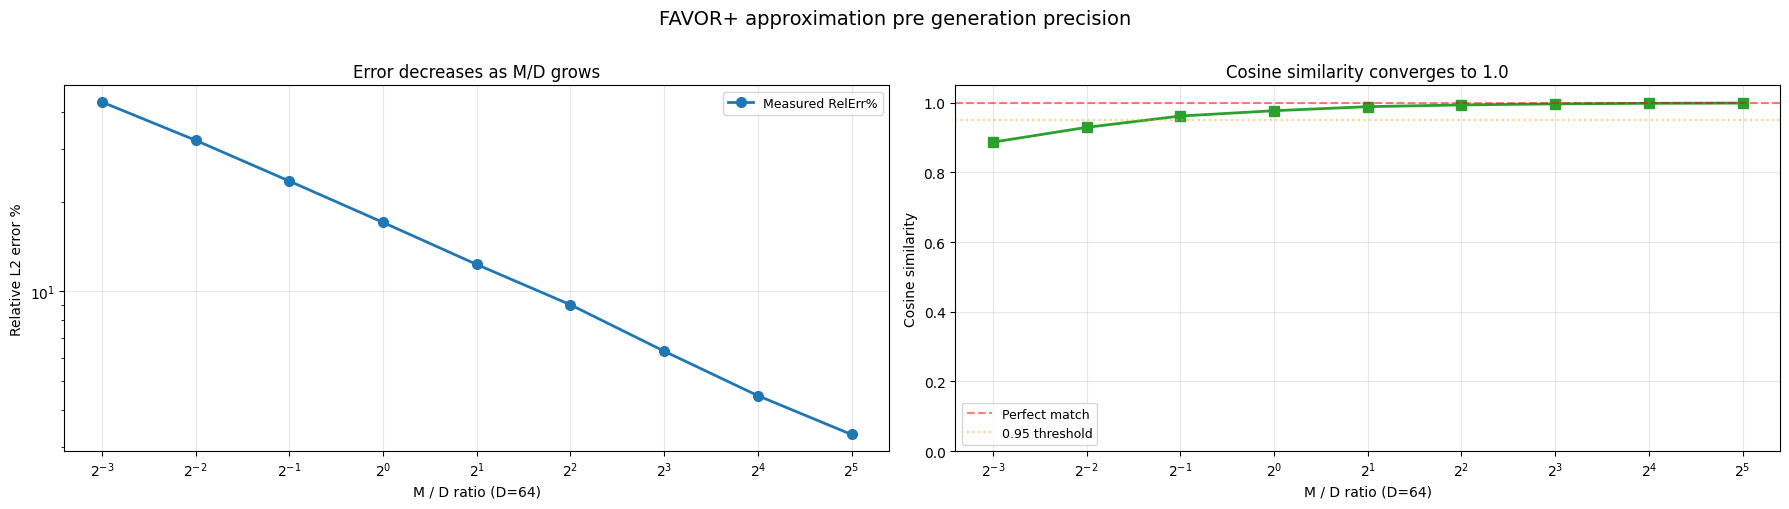

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ----------------------------
# Error vs M/D
# ----------------------------

ax = axes[0]
g2_md = [r[0] / D for r in g2_results]
g2_rels = [r[3] * 100 for r in g2_results]
ax.plot(g2_md, g2_rels, 'o-', linewidth=2, color='tab:blue', label='Measured RelErr%', markersize=7)
ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('Relative L2 error %')
ax.set_title('Error decreases as M/D grows')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ----------------------------
# Cosine vs M/D
# ----------------------------

ax = axes[1]
g2_coss = [r[2] for r in g2_results]
ax.plot(g2_md, g2_coss, 's-', linewidth=2, color='tab:green', markersize=7)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect match')
ax.axhline(y=0.95, color='orange', linestyle=':', alpha=0.5, label='0.95 threshold')
ax.set_xlabel(f'M / D ratio (D={D})')
ax.set_ylabel('Cosine similarity')
ax.set_title('Cosine similarity converges to 1.0')
ax.set_xscale('log', base=2)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'FAVOR+ approximation pre generation precision', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [84]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    As more features are sampled with ORF, the approximation converges towards softmax and
    outputs with identical random vectors in entry converge towards same value. Error decreases and
    cosine similarity converges to 1.
  </h1>
</div>

## **3.2 Attention weight comparaison – pattern similarity**

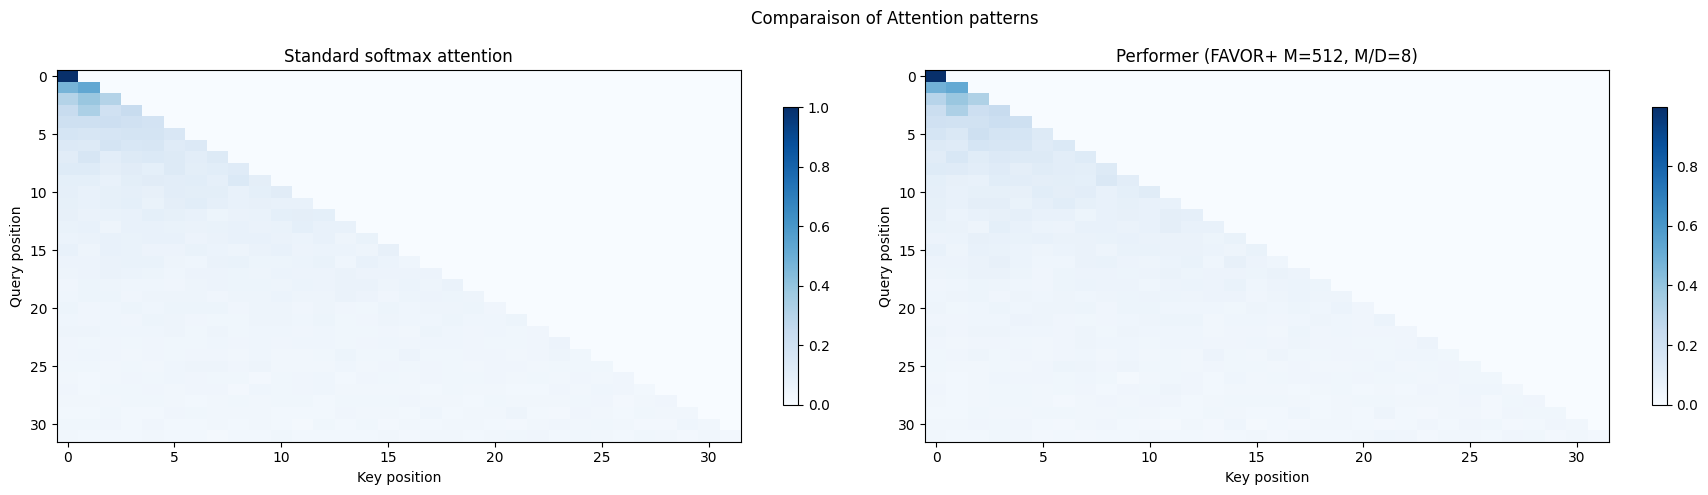

In [85]:
torch.manual_seed(42)
N_vis = 32
q = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32) * ELEM_STD
k = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32) * ELEM_STD
v = torch.randn(1, 1, N_vis, D, device=_dev, dtype=torch.float32)

with torch.no_grad():
    _, w_std = causal_softmax_attention(q, k, v)
w_std = w_std[0, 0].cpu()

core_vis = PerformerAttentionCore(head_dim=D, num_features=512).to(_dev)
with torch.no_grad():
    scale = D ** -0.25
    phi_q = core_vis.phi(q * scale, is_query=True)
    phi_k = core_vis.phi(k * scale, is_query=False)
    w_perf = torch.matmul(phi_q, phi_k.transpose(-2, -1))[0, 0]
    causal_mask = torch.triu(torch.ones(N_vis, N_vis, device=_dev), diagonal=1).bool()
    w_perf.masked_fill_(causal_mask, 0.0)
    w_perf = w_perf / (w_perf.sum(dim=-1, keepdim=True) + 1e-6)
w_perf = w_perf.cpu()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

im0 = axes[0].imshow(w_std.numpy(), cmap='Blues', aspect='auto')
axes[0].set_title('Standard softmax attention')
axes[0].set_xlabel('Key position')
axes[0].set_ylabel('Query position')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(w_perf.numpy(), cmap='Blues', aspect='auto')
axes[1].set_title(f'Performer (FAVOR+ M=512, M/D={512//D})')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

diff = (w_std - w_perf).abs().numpy()

plt.suptitle('Comparaison of Attention patterns')
plt.tight_layout()
plt.show()

frob = torch.norm(w_std - w_perf, p='fro').item()

In [86]:
# @title
%%html
<div style="
  background-color: lightyellow;
  padding: 20px 24px;
  border-radius: 12px;
  text-align: left;
">
  <h1 style="
    margin: 0;
    color: #000000;
    font-size: 15px;
    font-weight: 400;
    font-family: Arial, sans-serif;
    line-height: 1.4;
  ">
    Attention weight patterns are similar for approximation and softmax
  </h1>
</div>